In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from GG4 import Brain

sys.path.insert(0, str((Path(".").resolve().parent / "shared")))
sys.path.insert(0, str(Path(".").resolve()))

from bode import (
    NOTEBOOK_GITHUB_URL,
    compute_analytic_bode,
    compute_empirical_bode,
    make_bode_figure,
)
from constants import (
    CAPTIONS_PATH,
    ERA_EM_PATHS,
    ERA_EM_COLOURS,
    FIGURES_PATH,
    LATENT_DIMS,
    N_FFT,
    N_MARKOV,
    RANDOM_SEED,
)
from era_utils import collect_markov_parameters
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from system_estimate import SystemEstimate

In [2]:
# (no notebook-specific constants)

In [3]:
# ── derived: Brain input dimension and ERA+EM estimates ───────────────────────
_b = Brain(random_seed=RANDOM_SEED)
P_DIM = _b.input_dim
del _b

ESTIMATES: list[SystemEstimate] = [SystemEstimate.load(p) for p in ERA_EM_PATHS]

for n_x, est in zip(LATENT_DIMS, ESTIMATES):
    print(f"n_x={n_x}  {est.label:20s}  A: {est.A.shape},  B: {est.B.shape},  C: {est.C.shape}")
print(f"n_u = {P_DIM}")

n_x=2  ERA+EM $n_x=2$        A: (2, 2),  B: (2, 2),  C: (16, 2)
n_x=4  ERA+EM $n_x=4$        A: (4, 4),  B: (4, 2),  C: (16, 4)
n_x=6  ERA+EM $n_x=6$        A: (6, 6),  B: (6, 2),  C: (16, 6)
n_u = 2


In [4]:
# ── simulation: collect Markov parameters and compute frequency responses ──────
markov = collect_markov_parameters(RANDOM_SEED, P_DIM, N_MARKOV)

freqs, H_emp = compute_empirical_bode(markov, n_fft=N_FFT)

model_responses: list[tuple[str, str, np.ndarray]] = [
    (est.label, colour, compute_analytic_bode(est.A, est.B, est.C, freqs))
    for est, colour in zip(ESTIMATES, ERA_EM_COLOURS)
]

print(f"Frequency grid: {len(freqs)} points in [0, π]")
print(f"H_emp: {H_emp.shape}")
for label, colour, H in model_responses:
    print(f"{label:25s}  H: {H.shape}")

Impulse responses:   0%|          | 0/2 [00:00<?, ?it/s]

Frequency grid: 257 points in [0, π]
H_emp: (257, 16, 2)
ERA+EM $n_x=2$             H: (257, 16, 2)
ERA+EM $n_x=4$             H: (257, 16, 2)
ERA+EM $n_x=6$             H: (257, 16, 2)


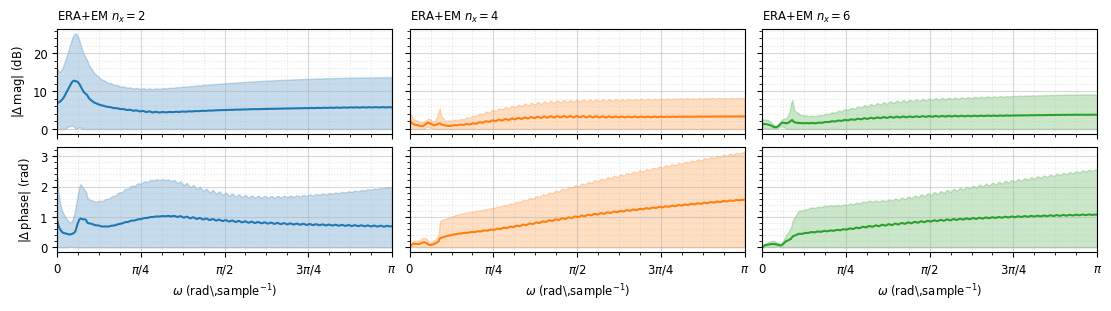

In [5]:
# ── display ────────────────────────────────────────────────────────────────────
configure_screen()
fig = make_bode_figure(freqs, H_emp, model_responses, figsize=(11, 3))
apply_figure_style(fig)
plt.show()

In [6]:
# ── pgf export ─────────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC  = 1.0   # fraction of A4 content width
FIG_HEIGHT_FRAC = 0.22  # fraction of A4 content height

configure_pgf()
fig = make_bode_figure(
    freqs, H_emp, model_responses,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "bode.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/bode.pgf


In [7]:
# ── caption ────────────────────────────────────────────────────────────────────
n_y   = ESTIMATES[0].C.shape[0]
dims_str = ", ".join(
    (str(d) if i < len(LATENT_DIMS) - 1 else f"and {d}")
    for i, d in enumerate(LATENT_DIMS)
)

caption = (
    r"Magnitude error (top row) and phase error (bottom row) of ERA+EM transfer functions for $n_x \in \{"
    + ", ".join(str(d) for d in LATENT_DIMS)
    + r"\}$ (left to right). "
    r"Each panel shows the absolute error between the exact empirical transfer function and the analytic "
    r"model response $H(\mathrm{e}^{\mathrm{j}\omega}) = C(\mathrm{e}^{\mathrm{j}\omega}I - A)^{-1}B$, "
    r"as mean $\pm$ 1 s.d.\ across all $n_u n_y = "
    + str(n_y * P_DIM)
    + r"$ output--input channels. "
    r"The empirical reference is the exact discrete-time frequency response "
    r"obtained via impulse subtraction (same-seed noise cancellation), "
    r"DFT zero-padded to "
    + str(N_FFT)
    + r" points. "
    r"Columns share a common $x$-axis; rows share a common $y$-axis."
)
save_caption(CAPTIONS_PATH / "bode.tex", caption, NOTEBOOK_GITHUB_URL)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/bode.tex
Magnitude error (top row) and phase error (bottom row) of ERA+EM transfer functions for $n_x \in \{2, 4, 6\}$ (left to right). Each panel shows the absolute error between the exact empirical transfer function and the analytic model response $H(\mathrm{e}^{\mathrm{j}\omega}) = C(\mathrm{e}^{\mathrm{j}\omega}I - A)^{-1}B$, as mean $\pm$ 1 s.d.\ across all $n_u n_y = 32$ output--input channels. The empirical reference is the exact discrete-time frequency response obtained via impulse subtraction (same-seed noise cancellation), DFT zero-padded to 512 points. Columns share a common $x$-axis; rows share a common $y$-axis.
